In [2]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - later use
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report

# Warnings
import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("Steel_industry_data.csv")

In [4]:
df

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.00,0.0,73.21,100.00,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.00,0.0,66.77,100.00,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.00,0.0,70.28,100.00,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.00,0.0,68.09,100.00,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.00,0.0,64.72,100.00,4500,Weekday,Monday,Light_Load
...,...,...,...,...,...,...,...,...,...,...,...
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (35040, 11)

Columns:
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']


In [6]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,35040,35040,01/01/2018 00:15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Usage_kWh,35040.0,NaN,NaN,NaN,27.386892,33.44438,0.0,3.2,4.57,51.2375,157.18
Lagging_Current_Reactive.Power_kVarh,35040.0,NaN,NaN,NaN,13.035384,16.306,0.0,2.3,5.0,22.64,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,NaN,NaN,NaN,3.870949,7.424463,0.0,0.0,0.0,2.09,27.76
CO2(tCO2),35040.0,NaN,NaN,NaN,0.011524,0.016151,0.0,0.0,0.0,0.02,0.07
Lagging_Current_Power_Factor,35040.0,NaN,NaN,NaN,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.0
Leading_Current_Power_Factor,35040.0,NaN,NaN,NaN,84.36787,30.456535,0.0,99.7,100.0,100.0,100.0
NSM,35040.0,NaN,NaN,NaN,42750.0,24940.534317,0.0,21375.0,42750.0,64125.0,85500.0
WeekStatus,35040,2,Weekday,25056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_week,35040,7,Monday,5088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64


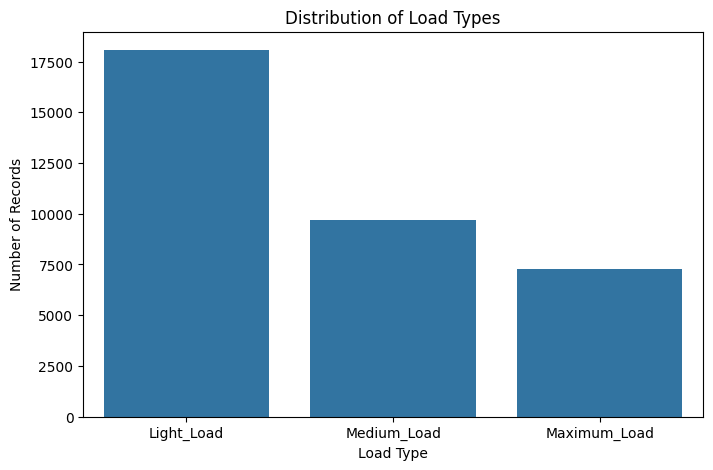

In [10]:
print(df["Load_Type"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Load_Type")
plt.title("Distribution of Load Types")
plt.xlabel("Load Type")
plt.ylabel("Number of Records")
plt.show()

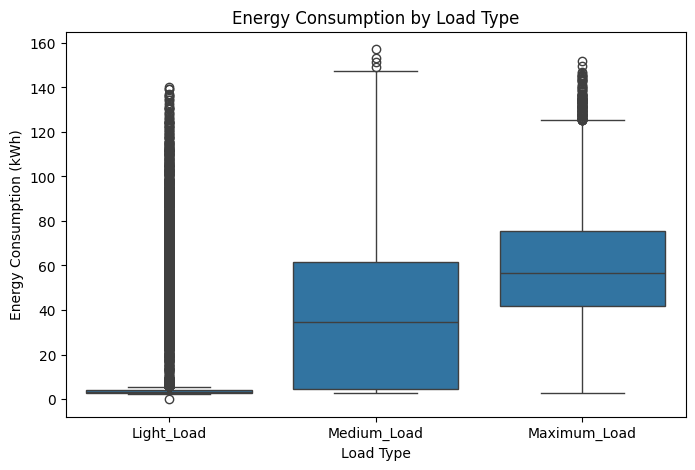

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Load_Type", y="Usage_kWh")
plt.title("Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Energy Consumption (kWh)")
plt.show()

WeekStatus
Weekday    25056
Weekend     9984
Name: count, dtype: int64


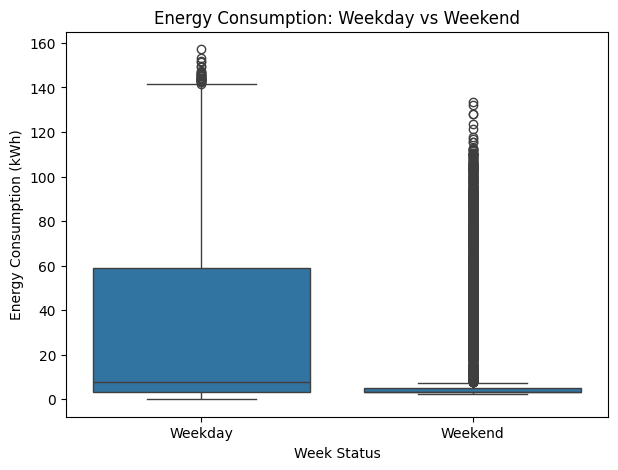

In [12]:
print(df["WeekStatus"].value_counts())

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="WeekStatus", y="Usage_kWh")
plt.title("Energy Consumption: Weekday vs Weekend")
plt.xlabel("Week Status")
plt.ylabel("Energy Consumption (kWh)")
plt.show()

In [13]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].min())
print(df["date"].max())

ValueError: time data "13/01/2018 00:15" doesn't match format "%m/%d/%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [14]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y %H:%M"
)

print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Start date: 2018-01-01 00:00:00
End date: 2018-12-31 23:45:00


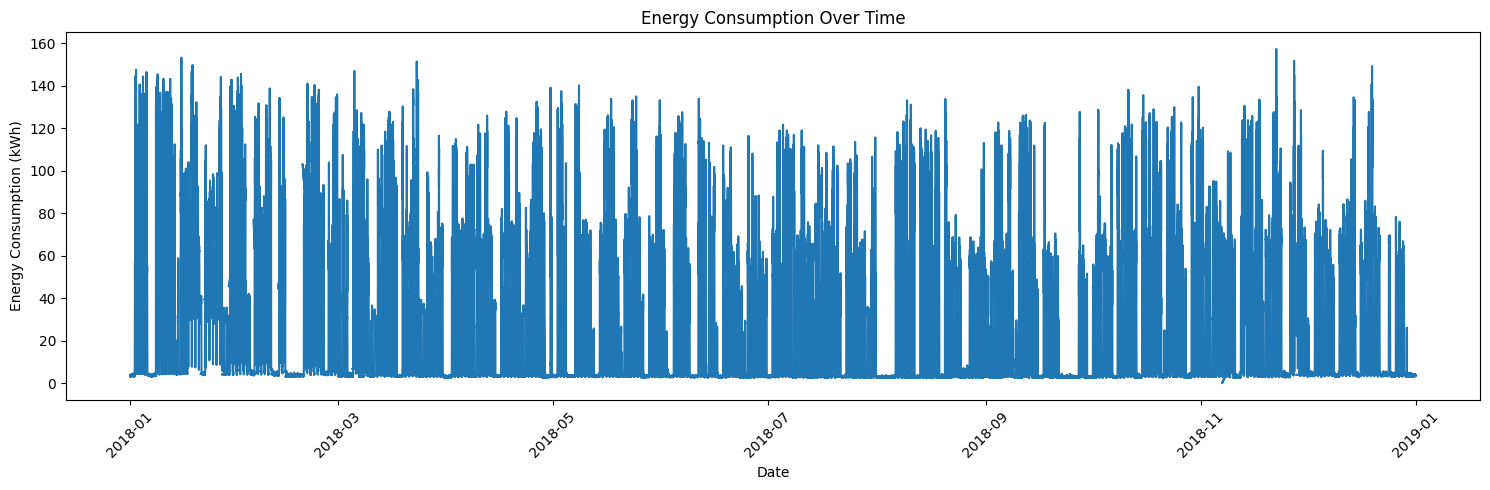

In [15]:
plt.figure(figsize=(15,5))

plt.plot(df["date"], df["Usage_kWh"])

plt.title("Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

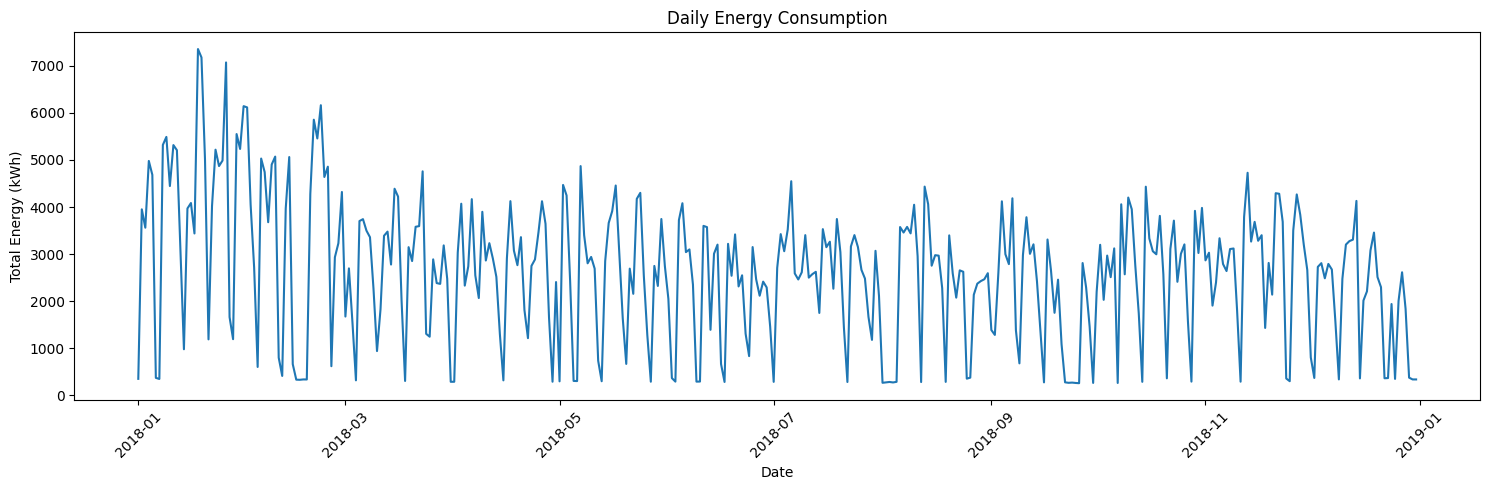

In [16]:
daily_energy = df.groupby(df["date"].dt.date)["Usage_kWh"].sum()

plt.figure(figsize=(15,5))

plt.plot(daily_energy.index, daily_energy.values)

plt.title("Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Total Energy (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
top_energy = df.nlargest(10, "Usage_kWh")

top_energy[[
    "date",
    "Usage_kWh",
    "Load_Type",
    "WeekStatus",
    "Day_of_week"
]]

,date,Usage_kWh,Load_Type,WeekStatus,Day_of_week
31238,2018-11-22 09:45:00,157.18,Medium_Load,Weekday,Thursday
1398,2018-01-15 13:45:00,153.14,Medium_Load,Weekday,Monday
31723,2018-11-27 11:00:00,151.67,Maximum_Load,Weekday,Tuesday
7812,2018-03-23 09:15:00,151.31,Medium_Load,Weekday,Friday
1701,2018-01-18 17:30:00,149.65,Maximum_Load,Weekday,Thursday
33848,2018-12-19 14:15:00,149.18,Medium_Load,Weekday,Wednesday
162,2018-01-02 16:45:00,147.46,Medium_Load,Weekday,Tuesday
6111,2018-03-05 16:00:00,146.88,Maximum_Load,Weekday,Monday
1679,2018-01-18 12:00:00,146.48,Maximum_Load,Weekday,Thursday
447,2018-01-05 16:00:00,146.34,Medium_Load,Weekday,Friday


In [18]:
load_analysis = df.groupby("Load_Type")["Usage_kWh"].agg(
    ["count", "mean", "median", "max"]
)

load_analysis

,count,mean,median,max
Load_Type,,,,
Light_Load,18072,8.626207,3.310,140.29
Maximum_Load,7272,59.265314,56.630,151.67
Medium_Load,9696,38.445394,34.435,157.18


In [19]:
day_analysis = df.groupby("Day_of_week")["Usage_kWh"].agg(
    ["count", "mean", "median", "max"]
)

day_analysis

,count,mean,median,max
Day_of_week,,,,
Friday,4992,33.195014,9.02,151.31
Monday,5088,33.143935,6.28,153.14
Saturday,4992,15.919020,3.74,133.42
Sunday,4992,7.545633,3.20,116.78
Thursday,4992,35.112083,19.85,157.18
Tuesday,4992,34.427614,9.29,151.67
Wednesday,4992,32.254235,5.85,149.18


In [20]:
hourly_analysis = df.groupby(
    df["date"].dt.hour
)["Usage_kWh"].agg(
    ["count", "mean", "median", "max"]
)

hourly_analysis

,count,mean,median,max
date,,,,
0,1460,7.870075,3.475,105.55
1,1460,6.072479,3.350,104.94
2,1460,4.428390,3.200,87.73
3,1460,4.358041,3.130,87.55
4,1460,4.309438,3.130,92.12
5,1460,4.245548,3.130,91.84
6,1460,4.223705,3.100,92.66
7,1460,4.502075,3.310,91.66
8,1460,37.704795,34.700,137.09


Task was destroyed but it is pending!
task: <Task pending name='Task-161' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Python314\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-162' coro=<Kernel.shell_main() running at C:\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Python314\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-162' coro=<Kernel.shell_main() running at C:\Python314\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


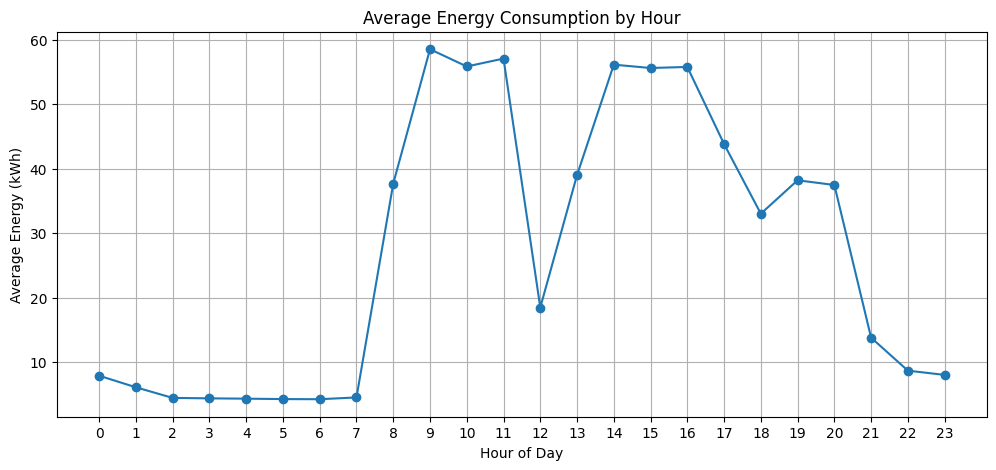

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    hourly_analysis.index,
    hourly_analysis["mean"],
    marker="o"
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy (kWh)")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [22]:
pf_analysis = df[[
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor"
]].describe()

pf_analysis

,Lagging_Current_Power_Factor,Leading_Current_Power_Factor
count,35040.000000,35040.000000
mean,80.578056,84.367870
std,18.921322,30.456535
min,0.000000,0.000000
25%,63.320000,99.700000
50%,87.960000,100.000000
75%,99.022500,100.000000
max,100.000000,100.000000


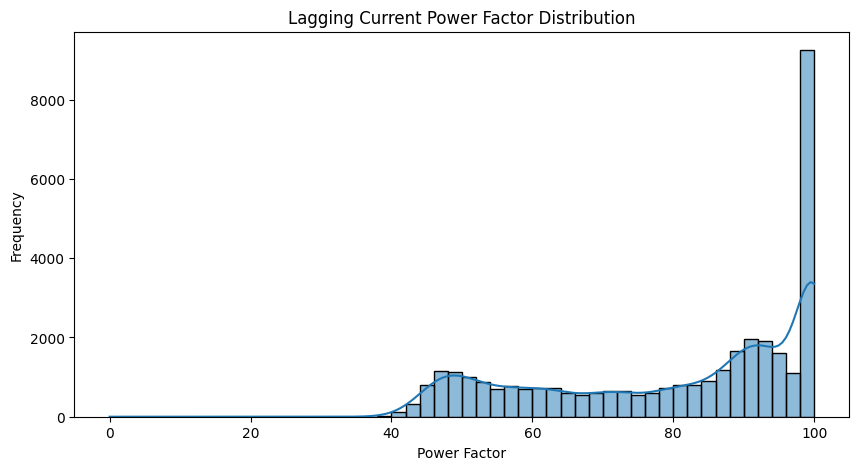

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Lagging_Current_Power_Factor"],
    bins=50,
    kde=True
)

plt.title("Lagging Current Power Factor Distribution")
plt.xlabel("Power Factor")
plt.ylabel("Frequency")

plt.show()

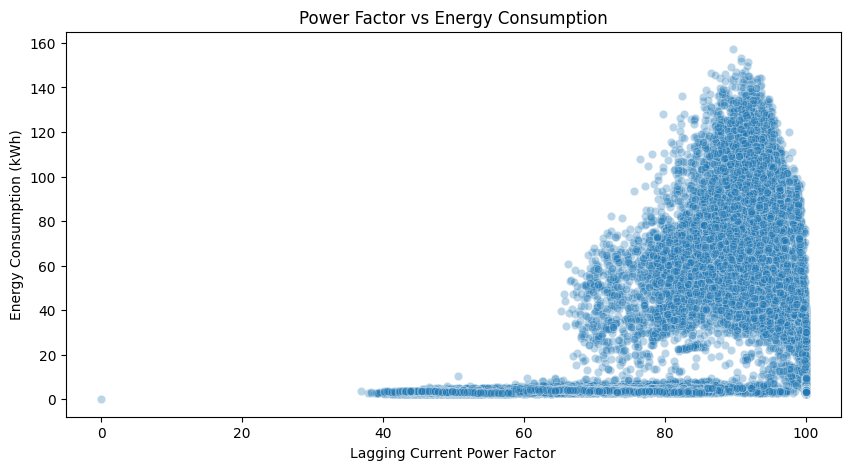

In [24]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="Lagging_Current_Power_Factor",
    y="Usage_kWh",
    alpha=0.3
)

plt.title("Power Factor vs Energy Consumption")
plt.xlabel("Lagging Current Power Factor")
plt.ylabel("Energy Consumption (kWh)")

plt.show()

In [26]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

correlation = df[numeric_cols].corr()

correlation["Usage_kWh"].sort_values(ascending=False)

Usage_kWh                               1.000000
CO2(tCO2)                               0.988180
Lagging_Current_Reactive.Power_kVarh    0.896150
Lagging_PF                              0.385960
Lagging_Current_Power_Factor            0.385960
Leading_Current_Power_Factor            0.353566
NSM                                     0.234610
Leading_Current_Reactive_Power_kVarh   -0.324922
Name: Usage_kWh, dtype: float64

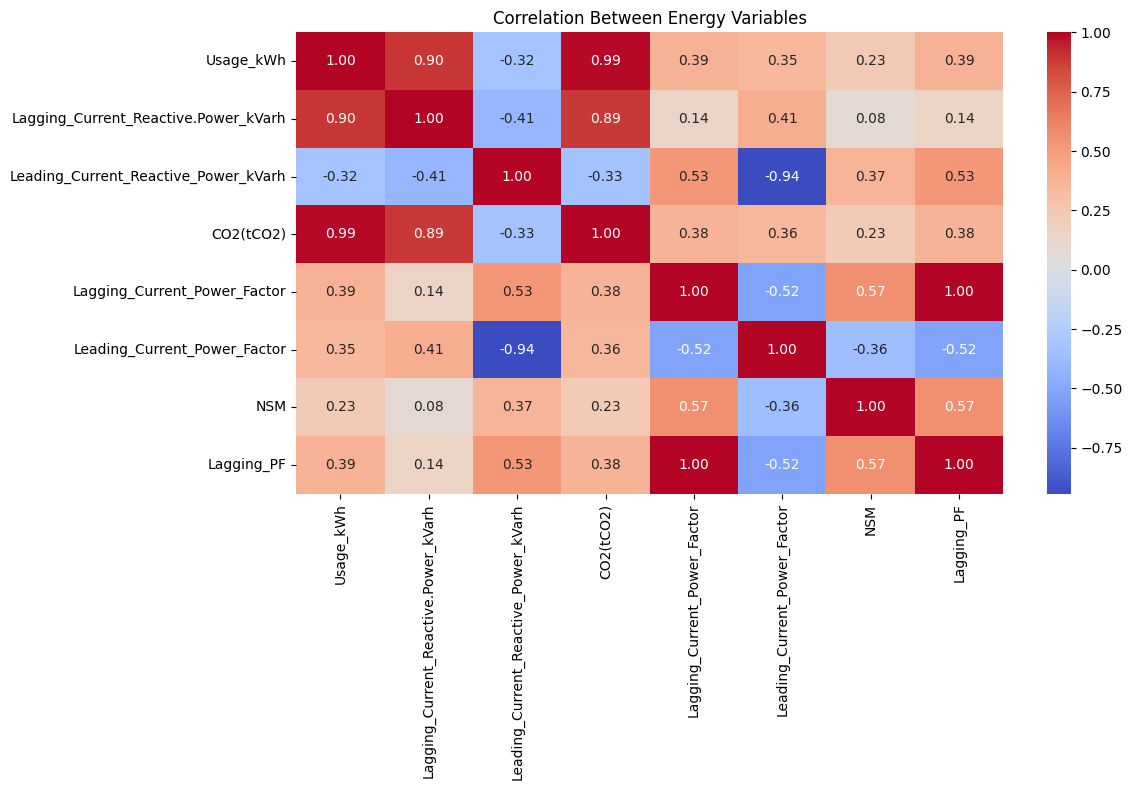

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Energy Variables")
plt.tight_layout()
plt.show()

In [28]:
co2_analysis = df["CO2(tCO2)"].describe()

co2_analysis

count    35040.000000
mean         0.011524
std          0.016151
min          0.000000
25%          0.000000
50%          0.000000
75%          0.020000
max          0.070000
Name: CO2(tCO2), dtype: float64

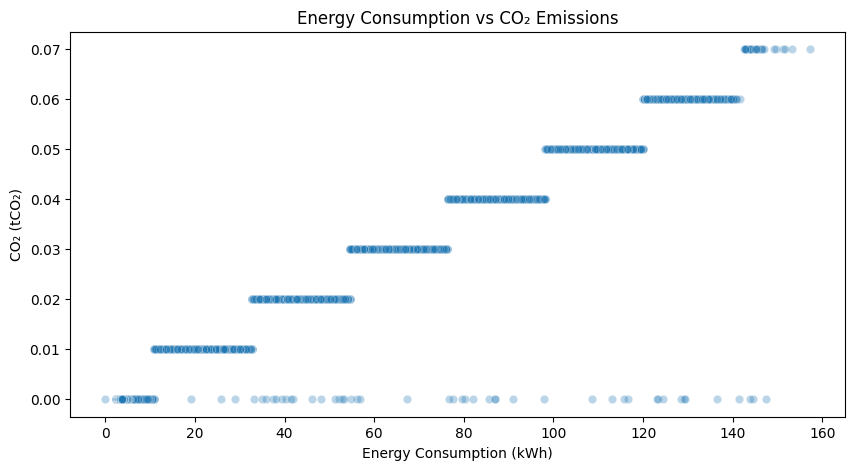

In [29]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="Usage_kWh",
    y="CO2(tCO2)",
    alpha=0.3
)

plt.title("Energy Consumption vs CO₂ Emissions")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("CO₂ (tCO₂)")

plt.show()

In [30]:
total_energy = df["Usage_kWh"].sum()
total_co2 = df["CO2(tCO2)"].sum()

print("Total Energy Consumption:", round(total_energy, 2), "kWh")
print("Total CO₂ Emissions:", round(total_co2, 4), "tCO₂")

Total Energy Consumption: 959636.71 kWh
Total CO₂ Emissions: 403.81 tCO₂


In [31]:
co2_by_load = df.groupby("Load_Type")["CO2(tCO2)"].agg(
    ["count", "mean", "sum"]
)

co2_by_load

,count,mean,sum
Load_Type,,,
Light_Load,18072,0.002554,46.15
Maximum_Load,7272,0.026899,195.61
Medium_Load,9696,0.016713,162.05


In [32]:
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month

In [33]:
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_of_week_num"] = df["date"].dt.dayofweek

In [34]:
df["is_weekend"] = df["day_of_week_num"].isin([5, 6]).astype(int)

In [35]:
df["is_peak_hour"] = df["hour"].between(9, 16).astype(int)

In [36]:
df[[
    "date",
    "hour",
    "day",
    "month",
    "day_of_week_num",
    "is_weekend",
    "is_peak_hour"
]].head(10)

,date,hour,day,month,day_of_week_num,is_weekend,is_peak_hour
0,2018-01-01 00:15:00,0,1,1,0,0,0
1,2018-01-01 00:30:00,0,1,1,0,0,0
2,2018-01-01 00:45:00,0,1,1,0,0,0
3,2018-01-01 01:00:00,1,1,1,0,0,0
4,2018-01-01 01:15:00,1,1,1,0,0,0
5,2018-01-01 01:30:00,1,1,1,0,0,0
6,2018-01-01 01:45:00,1,1,1,0,0,0
7,2018-01-01 02:00:00,2,1,1,0,0,0
8,2018-01-01 02:15:00,2,1,1,0,0,0
9,2018-01-01 02:30:00,2,1,1,0,0,0


In [37]:
print("Weekend records:")
print(df["is_weekend"].value_counts())

print("\nPeak-hour records:")
print(df["is_peak_hour"].value_counts())

Weekend records:
is_weekend
0    25056
1     9984
Name: count, dtype: int64

Peak-hour records:
is_peak_hour
0    23360
1    11680
Name: count, dtype: int64


In [38]:
features = [
    "hour",
    "day",
    "month",
    "day_of_week_num",
    "is_weekend",
    "is_peak_hour",
    "NSM",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor"
]

X = df[features]
y = df["Usage_kWh"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures used:")
print(features)

X shape: (35040, 11)
y shape: (35040,)

Features used:
['hour', 'day', 'month', 'day_of_week_num', 'is_weekend', 'is_peak_hour', 'NSM', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']


In [39]:
# Time-based train-test split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 28032
Testing samples: 7008


In [40]:
# Random Forest Energy Prediction Model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [41]:
# Predict energy consumption
y_pred = model.predict(X_test)

print("Predictions generated:", len(y_pred))
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated: 7008
First 10 predictions:
[64.2415 44.7627 18.2951  7.1901  5.6971  4.8482  4.6526  4.5724  3.597
  3.5643]


In [42]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = model.score(X_test, y_test)

print("Model Performance")
print("------------------")
print(f"MAE  : {mae:.2f} kWh")
print(f"RMSE : {rmse:.2f} kWh")
print(f"R²   : {r2:.4f}")

Model Performance
------------------
MAE  : 0.41 kWh
RMSE : 1.43 kWh
R²   : 0.9979


In [43]:
# Calculate prediction error / energy deviation

results = X_test.copy()

results["Actual_kWh"] = y_test.values
results["Predicted_kWh"] = y_pred

results["Energy_Deviation"] = (
    results["Actual_kWh"] - results["Predicted_kWh"]
)

results["Deviation_%"] = (
    results["Energy_Deviation"]
    / results["Predicted_kWh"]
) * 100

print(results[
    ["Actual_kWh", "Predicted_kWh", "Energy_Deviation", "Deviation_%"]
].head(10))

       Actual_kWh  Predicted_kWh  Energy_Deviation  Deviation_%
28032       64.33        64.2415            0.0885     0.137761
28033       45.22        44.7627            0.4573     1.021610
28034       19.84        18.2951            1.5449     8.444338
28035        7.09         7.1901           -0.1001    -1.392192
28036        5.72         5.6971            0.0229     0.401959
28037        4.75         4.8482           -0.0982    -2.025494
28038        4.68         4.6526            0.0274     0.588918
28039        4.64         4.5724            0.0676     1.478436
28040        3.60         3.5970            0.0030     0.083403
28041        3.56         3.5643           -0.0043    -0.120641


In [44]:
# Calculate anomaly threshold from prediction errors

positive_deviations = results["Energy_Deviation"][
    results["Energy_Deviation"] > 0
]

threshold = positive_deviations.quantile(0.95)

print(f"95th percentile positive deviation: {threshold:.2f} kWh")

95th percentile positive deviation: 3.04 kWh


In [45]:
# Flag unusually high energy consumption

results["Energy_Anomaly"] = (
    results["Energy_Deviation"] > threshold
).astype(int)

print("\nAnomaly distribution:")
print(results["Energy_Anomaly"].value_counts())

print("\nAnomaly percentage:")
print(
    results["Energy_Anomaly"].mean() * 100,
    "%"
)


Anomaly distribution:
Energy_Anomaly
0    6792
1     216
Name: count, dtype: int64

Anomaly percentage:
3.0821917808219177 %


In [46]:
# Inspect the highest energy anomalies

anomalies = results[
    results["Energy_Anomaly"] == 1
].copy()

anomalies = anomalies.sort_values(
    "Energy_Deviation",
    ascending=False
)

print("Total anomalies:", len(anomalies))

print(
    anomalies[
        [
            "Actual_kWh",
            "Predicted_kWh",
            "Energy_Deviation",
            "Deviation_%",
            "hour",
            "is_weekend",
            "is_peak_hour",
            "NSM",
            "Lagging_Current_Reactive.Power_kVarh",
            "Leading_Current_Reactive_Power_kVarh",
            "Lagging_Current_Power_Factor",
            "Leading_Current_Power_Factor"
        ]
    ].head(10)
)

Total anomalies: 216
       Actual_kWh  Predicted_kWh  Energy_Deviation  Deviation_%  hour  \
31187       47.63        29.1239           18.5061    63.542657    21   
29171       45.07        27.2173           17.8527    65.593207    21   
34637       47.99        30.9219           17.0681    55.197449    19   
31238      157.18       140.3018           16.8782    12.029924     9   
32677       49.50        33.2652           16.2348    48.804156     9   
32678       48.42        33.0439           15.3761    46.532340     9   
32680       48.02        33.0613           14.9587    45.245347    10   
32611       47.77        33.3582           14.4118    43.203170    17   
32612       48.60        34.2727           14.3273    41.803826    17   
32687       44.28        30.1349           14.1451    46.939263    12   

       is_weekend  is_peak_hour    NSM  Lagging_Current_Reactive.Power_kVarh  \
31187           0             0  75600                                  6.77   
29171          

In [47]:
# Compare normal and anomalous energy events

comparison = results.groupby("Energy_Anomaly")[
    [
        "Actual_kWh",
        "Predicted_kWh",
        "Energy_Deviation",
        "Deviation_%",
        "Lagging_Current_Reactive.Power_kVarh",
        "Leading_Current_Reactive_Power_kVarh",
        "Lagging_Current_Power_Factor",
        "Leading_Current_Power_Factor"
    ]
].mean()

print(comparison)

                Actual_kWh  Predicted_kWh  Energy_Deviation  Deviation_%  \
Energy_Anomaly                                                             
0                24.654993      24.620800          0.034193     0.346368   
1                43.371574      36.826903          6.544671    21.348420   

                Lagging_Current_Reactive.Power_kVarh  \
Energy_Anomaly                                         
0                                          12.273192   
1                                           8.242037   

                Leading_Current_Reactive_Power_kVarh  \
Energy_Anomaly                                         
0                                           3.972013   
1                                           2.105556   

                Lagging_Current_Power_Factor  Leading_Current_Power_Factor  
Energy_Anomaly                                                              
0                                  82.611279                     83.177794  
1             

In [48]:
# Compare operating conditions

operating_comparison = results.groupby("Energy_Anomaly")[
    [
        "hour",
        "is_weekend",
        "is_peak_hour",
        "NSM"
    ]
].mean()

print(operating_comparison)

                     hour  is_weekend  is_peak_hour           NSM
Energy_Anomaly                                                   
0               11.376178    0.303740      0.327886  42302.120141
1               15.393519    0.226852      0.504630  56833.333333


In [49]:
def generate_recommendation(row):

    if row["Energy_Anomaly"] == 0:
        return "Normal energy consumption"

    if row["is_peak_hour"] == 1:
        return (
            "High energy deviation during peak operating period. "
            "Review machine loading, operating schedule and production activity."
        )

    return (
        "Unexpected energy consumption detected. "
        "Inspect machine operating conditions and production activity."
    )


results["AI_Recommendation"] = results.apply(
    generate_recommendation,
    axis=1
)

print(
    results[
        [
            "Actual_kWh",
            "Predicted_kWh",
            "Deviation_%",
            "Energy_Anomaly",
            "AI_Recommendation"
        ]
    ].tail(20)
)

       Actual_kWh  Predicted_kWh  Deviation_%  Energy_Anomaly  \
35020        3.96         3.9427     0.438786               0   
35021        4.14         4.0980     1.024890               0   
35022        4.21         4.1562     1.294452               0   
35023        4.14         4.1134     0.646667               0   
35024        4.18         4.1074     1.767542               0   
35025        3.38         3.3580     0.655152               0   
35026        3.42         3.4154     0.134684               0   
35027        3.42         3.4254    -0.157646               0   
35028        3.42         3.4101     0.290314               0   
35029        3.49         3.5144    -0.694286               0   
35030        3.42         3.4276    -0.221729               0   
35031        3.42         3.4394    -0.564052               0   
35032        3.24         3.2569    -0.518898               0   
35033        3.67         3.6615     0.232145               0   
35034        3.82        

In [50]:
def get_severity(row):

    if row["Energy_Anomaly"] == 0:
        return "Normal"

    if row["Deviation_%"] >= 40:
        return "High"

    if row["Deviation_%"] >= 20:
        return "Medium"

    return "Low"


results["Severity"] = results.apply(
    get_severity,
    axis=1
)

print(results["Severity"].value_counts())

Severity
Normal    6792
Low        112
Medium      91
High        13
Name: count, dtype: int64


In [51]:
print(
    results[
        results["Energy_Anomaly"] == 1
    ][
        [
            "Actual_kWh",
            "Predicted_kWh",
            "Deviation_%",
            "Severity",
            "AI_Recommendation"
        ]
    ].head(10)
)

       Actual_kWh  Predicted_kWh  Deviation_% Severity  \
28961      134.60       130.5637     3.091441      Low   
28979       31.50        27.9177    12.831644      Low   
29062       30.10        26.2041    14.867521      Low   
29063       30.89        27.7401    11.355042      Low   
29171       45.07        27.2173    65.593207     High   
29254       36.25        31.5017    15.073155      Low   
29413       38.12        33.2034    14.807520      Low   
29414       57.24        53.9430     6.112007      Low   
29430       71.53        68.4931     4.433877      Low   
29432       61.27        56.7259     8.010627      Low   

                                       AI_Recommendation  
28961  High energy deviation during peak operating pe...  
28979  Unexpected energy consumption detected. Inspec...  
29062  Unexpected energy consumption detected. Inspec...  
29063  Unexpected energy consumption detected. Inspec...  
29171  Unexpected energy consumption detected. Inspec...  
29254  

In [52]:
import joblib

joblib.dump(model, "energy_model.pkl")

print("Energy model saved successfully!")

Energy model saved successfully!


In [53]:
joblib.dump(threshold, "energy_threshold.pkl")

print("Energy threshold saved successfully!")

Energy threshold saved successfully!


In [54]:
import os
print(os.getcwd())

C:\Users\SHEETAL\factory-ai-app\data


In [1]:
import joblib
from pathlib import Path

project_path = Path.cwd()

print("Current folder:", project_path)

Current folder: C:\Users\SHEETAL\factory-ai-app\data


In [2]:
import joblib
from pathlib import Path

project_path = Path.cwd()

joblib.dump(model, project_path / "energy_model.pkl")
joblib.dump(threshold, project_path / "energy_threshold.pkl")

print("Model saved:", (project_path / "energy_model.pkl").exists())
print("Threshold saved:", (project_path / "energy_threshold.pkl").exists())

NameError: name 'model' is not defined

In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestRegressor

In [4]:
df = pd.read_csv("data/Steel_industry_data.csv")

df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y %H:%M"
)

FileNotFoundError: [Errno 2] No such file or directory: 'data/Steel_industry_data.csv'

In [5]:
from pathlib import Path

print(Path.cwd())

C:\Users\SHEETAL\factory-ai-app\data


In [6]:
df = pd.read_csv(
    r"C:\Users\SHEETAL\factory-ai-app\data\Steel_industry_data.csv"
)

df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y %H:%M"
)

print(df.shape)

(35040, 11)


In [7]:
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_of_week_num"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week_num"].isin([5, 6]).astype(int)
df["is_peak_hour"] = df["hour"].between(9, 16).astype(int)

features = [
    "hour",
    "day",
    "month",
    "day_of_week_num",
    "is_weekend",
    "is_peak_hour",
    "NSM",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor"
]

X = df[features]
y = df["Usage_kWh"]

print("Features created:", X.shape)

Features created: (35040, 11)


In [8]:
from sklearn.ensemble import RandomForestRegressor

# Time-based 80/20 split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Train Random Forest
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Model trained successfully!
Training samples: 28032
Testing samples: 7008


In [9]:
results = X_test.copy()

results["Actual_kWh"] = y_test.values
results["Predicted_kWh"] = y_pred

results["Energy_Deviation"] = (
    results["Actual_kWh"] - results["Predicted_kWh"]
)

positive_deviations = results["Energy_Deviation"][
    results["Energy_Deviation"] > 0
]

threshold = positive_deviations.quantile(0.95)

print("Energy anomaly threshold:", threshold)

Energy anomaly threshold: 3.0363750000000103


In [10]:
import joblib

project_path = r"C:\Users\SHEETAL\factory-ai-app"

joblib.dump(
    model,
    project_path + r"\energy_model.pkl"
)

joblib.dump(
    threshold,
    project_path + r"\energy_threshold.pkl"
)

print("Model saved successfully!")
print("Threshold saved successfully!")

Model saved successfully!
Threshold saved successfully!


In [11]:
import os

print("Model exists:", os.path.exists(project_path + r"\energy_model.pkl"))
print("Threshold exists:", os.path.exists(project_path + r"\energy_threshold.pkl"))

Model exists: True
Threshold exists: True
